# 따릉이 수요 예측 시계열 분석 파이프라인


## 1. 라이브러리 로드 및 설정

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 통계 모델
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error

# auto_arima
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
    print("pmdarima loaded successfully")
except ImportError:
    HAS_PMDARIMA = False
    print("[Warning] pmdarima not found -> pip install pmdarima")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

pmdarima loaded successfully


In [3]:
# pip install pmdarima

## 2. 설정값 및 데이터 로드

In [4]:
# 설정값
DATA_DIR        = Path("data")          # filtered_YYYYMM.csv
SEASONAL_PERIOD = 24                    # 일일 계절 주기 (시간 단위 데이터이므로 S=24)
TEST_DAYS       = 30                    # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = "02128"               # 분석할 정류소 ID (변경 가능)

# 장기 결측 구간 (find_long_missing.py 기준)
LONG_MISSING = {
    "02185": [("2022-09-18", "2022-10-23")], # 36 days
    "02191": [("2022-10-05", "2022-10-21")], # 17 days
    "02199": [("2022-01-22", "2022-02-07")], # 17 days
}

In [5]:
#  데이터 로드
def load_filtered_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("filtered_2*.csv"))
    if not files:
        raise FileNotFoundError(f"filtered_*.csv 파일이 없습니다: {data_dir}")
    parts = [
        pd.read_csv(f, dtype={"RENT_DATE": str, "RENT_TIME": str,
                               "RENT_ID": str, "CNT": int})
        for f in files
    ]
    df = pd.concat(parts, ignore_index=True)
    # datetime 컬럼 생성
    df["datetime"] = pd.to_datetime(
        df["RENT_DATE"] + df["RENT_TIME"].str.zfill(2),
        format="%Y%m%d%H"
    )
    return df

df_raw = load_filtered_csvs(DATA_DIR)
print(f"전체 데이터: {df_raw.shape}")
print(f"날짜 범위: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")
print(f"정류소 수: {df_raw['RENT_ID'].nunique()}개")
print(f"정류소 목록: {sorted(df_raw['RENT_ID'].unique())}")
df_raw.head()

전체 데이터: (439021, 5)
날짜 범위: 2021-01-01 00:00:00 ~ 2025-12-31 23:00:00
정류소 수: 23개
정류소 목록: ['02111', '02112', '02116', '02122', '02128', '02129', '02130', '02139', '02143', '02148', '02159', '02171', '02172', '02178', '02179', '02185', '02186', '02191', '02198', '02199', '03310', '03311', '03802']


,RENT_DATE,RENT_TIME,RENT_ID,CNT,datetime
0,20210101,00,02128,1,2021-01-01 00:00:00
1,20210101,01,02112,1,2021-01-01 01:00:00
2,20210101,01,02129,1,2021-01-01 01:00:00
3,20210101,01,02171,1,2021-01-01 01:00:00
4,20210101,01,02172,1,2021-01-01 01:00:00


## 3. 데이터 전처리
**결측치 처리 전략** (`missing_value_report.md` 기준)
- 단기 (1~3일): 선형 보간
- 중기 (4~14일): 동일 요일+시간대 평균 대체  
- 장기 (15일 이상): NaN 유지 → 학습 윈도우에서 제외

In [6]:
def make_series(df: pd.DataFrame, rent_id: str) -> pd.Series:
    """
    특정 정류소의 시간별 CNT 시계열 생성
    - 전체 시간 인덱스로 reindex (이용 없는 시간대 = 0)
    - 장기 결측 구간은 NaN 처리
    - 단기/중기 결측 보간
    """
    sub = (
        df[df["RENT_ID"] == rent_id]
        .set_index("datetime")["CNT"]
        .sort_index()
    )

    # 전체 시간 인덱스 (1시간 단위)
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq="h")
    sub = sub.reindex(full_idx, fill_value=0).astype(float)

    # 장기 결측 구간 NaN 처리
    if rent_id in LONG_MISSING:
        for (start, end) in LONG_MISSING[rent_id]:
            sub[start:end] = np.nan

    # 연속 결측 길이 계산
    is_na = sub.isna()
    consec = is_na.astype(int).groupby((~is_na).cumsum()).cumsum()

    # 단기 결측 (≤72시간=3일): 선형 보간
    sub = sub.interpolate(method="linear", limit=72, limit_direction="both")

    # 중기 결측 (73~336시간=14일): 동일 요일+시간 평균
    still_na = sub.isna()
    if still_na.any():
        tmp_df = pd.DataFrame({
            "CNT": sub, "DOW": sub.index.dayofweek, "HOUR": sub.index.hour
        })
        mean_table = tmp_df.groupby(["DOW", "HOUR"])["CNT"].mean()
        for idx in sub[still_na].index:
            sub[idx] = mean_table.get((idx.dayofweek, idx.hour), 0)

    return sub


# 선택 정류소 시계열 생성
series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)


정류소 02128 시계열: 43,821시간
기간: 2021-01-01 00:00:00 ~ 2025-12-31 20:00:00
결측 수: 0


2021-01-01 00:00:00    1.0
2021-01-01 01:00:00    0.0
2021-01-01 02:00:00    0.0
2021-01-01 03:00:00    0.0
2021-01-01 04:00:00    0.0
2021-01-01 05:00:00    0.0
2021-01-01 06:00:00    0.0
2021-01-01 07:00:00    0.0
2021-01-01 08:00:00    0.0
2021-01-01 09:00:00    0.0
Freq: h, Name: CNT, dtype: float64

평일 데이터: 31,293시간
주말 데이터: 12,528시간


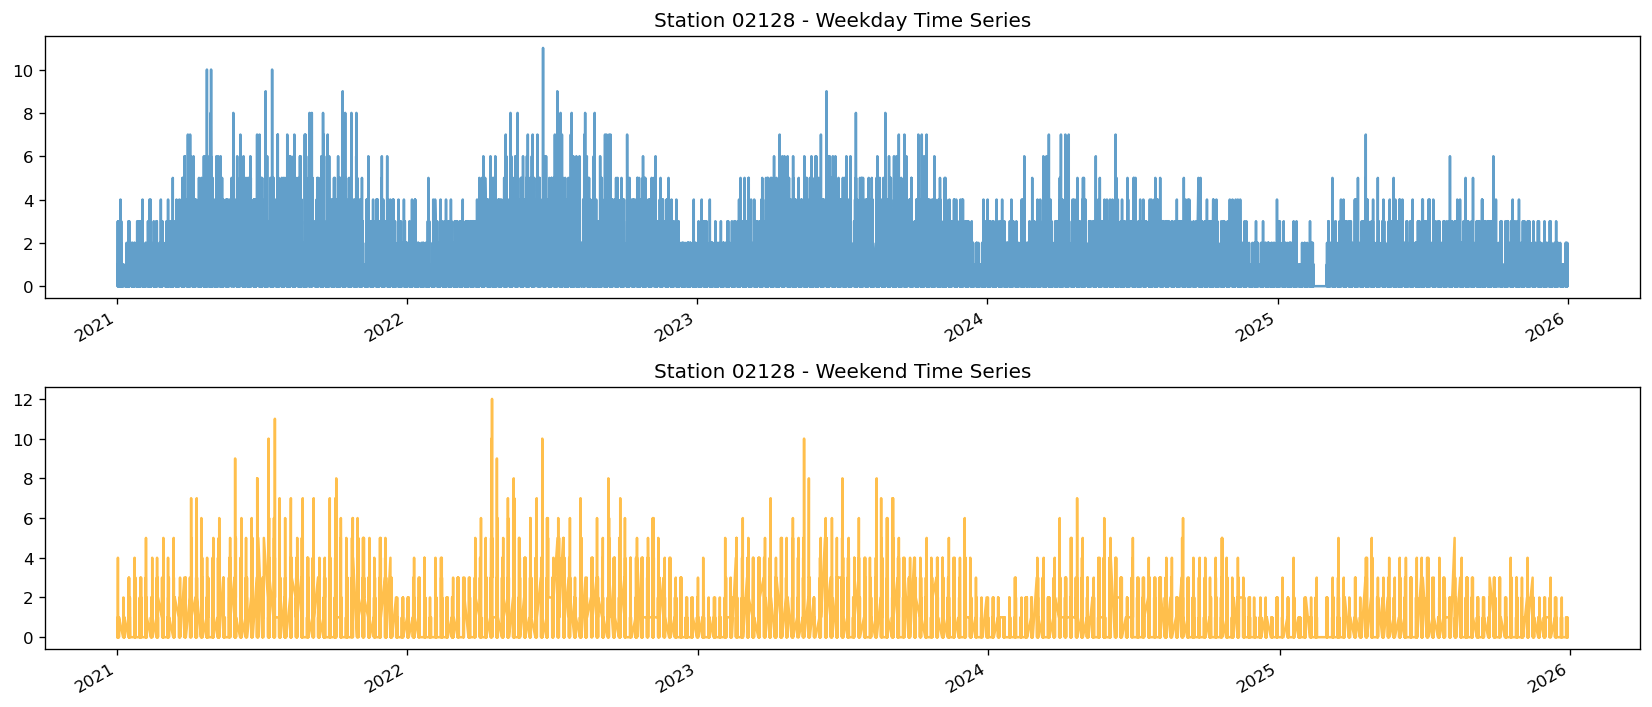

In [ ]:
# 평일 / 주말 분리
series_weekday = series[series.index.dayofweek < 5]
series_weekend = series[series.index.dayofweek >= 5]

print(f"평일 데이터: {len(series_weekday):,}시간")
print(f"주말 데이터: {len(series_weekend):,}시간")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
series_weekday.plot(ax=axes[0], title=f"Station {TARGET_RENT_ID} - Weekday Time Series", alpha=0.7)
series_weekend.plot(ax=axes[1], title=f"Station {TARGET_RENT_ID} - Weekend Time Series", color="orange", alpha=0.7)
plt.tight_layout()
plt.show()

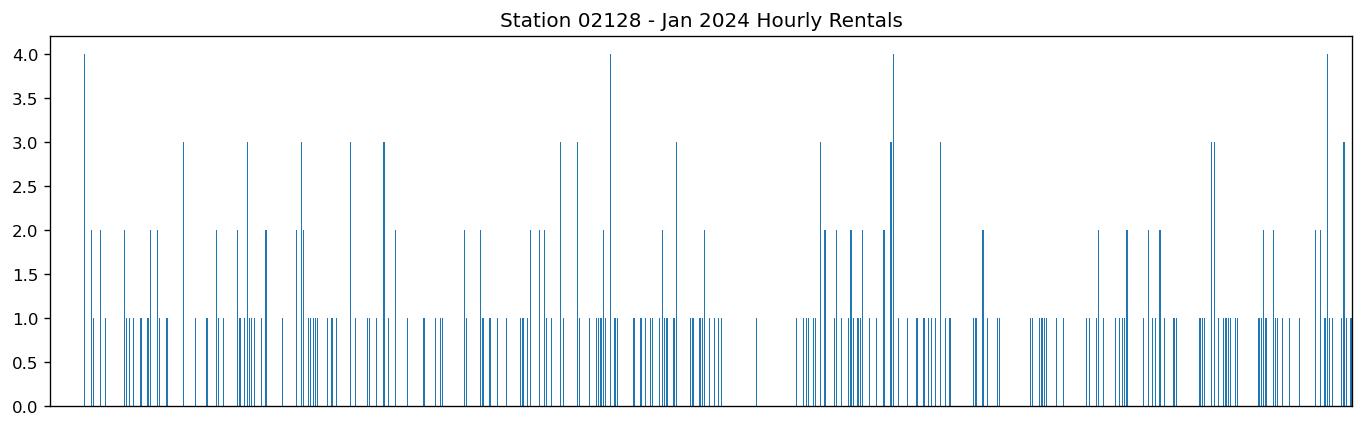

In [8]:
series_weekday["2024-01"].plot(
    kind="bar", figsize=(14, 4),
    title="Station 02128 - Jan 2024 Hourly Rentals"
)
plt.xticks([])  # x축 레이블 숨기기
plt.show()

In [ ]:
# Train / Test Split
# 이후 분석은 평일 데이터 기준
# 주말은 bicycle_forecast_weekend.ipynb
target_series = series_weekday.dropna()

test_hours = TEST_DAYS * 24
train = target_series.iloc[:-test_hours]
test  = target_series.iloc[-test_hours:]

print(f"Train: {train.index[0]} ~ {train.index[-1]} ({len(train):,}시간)")
print(f"Test : {test.index[0]} ~ {test.index[-1]} ({len(test):,}시간)")

Train: 2021-01-01 00:00:00 ~ 2025-11-19 20:00:00 (30,573시간)
Test : 2025-11-19 21:00:00 ~ 2025-12-31 20:00:00 (720시간)


## 4. 정상성 검정 — ADF Test
- $H_0$: 단위근 존재 (non-stationary)  
- $H_1$: 단위근 없음 (stationary)  
- p-value < 0.05이면 정상성 확보


In [ ]:
def adf_test(series: pd.Series, name: str = "", maxlag: int = 6):
    """ADF test"""
    result = adfuller(series.dropna(), maxlag=maxlag, autolag="AIC")
    print(f"[ADF Test] {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (1%) : {result[4]['1%']:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    stationary = result[1] < 0.05
    print(f"  결론          : {'정상 (stationary)' if stationary else '비정상 → 차분 필요'}")
    return stationary

# 원시계열 검정
print("=" * 50)
is_stationary = adf_test(train, name=f"Station {TARGET_RENT_ID} (raw)")

# 비정상이면 계절 차분 (S=24)
if not is_stationary:
    print(f"\nS={SEASONAL_PERIOD} 계절 차분 후 재검정...")
    train_diff = train.diff(SEASONAL_PERIOD).dropna()
    print("=" * 50)
    adf_test(train_diff, name=f"Station {TARGET_RENT_ID} (after seasonal diff)")
else:
    train_diff = train

[ADF Test] Station 02128 (raw)
  ADF Statistic : -53.1243
  p-value       : 0.0000
  Critical (1%) : -3.4306
  Critical (5%) : -2.8616
  결론          : 정상 (stationary)


## 5. ACF / PACF 시각화
차수 후보 파악: ACF → MA 차수, PACF → AR 차수


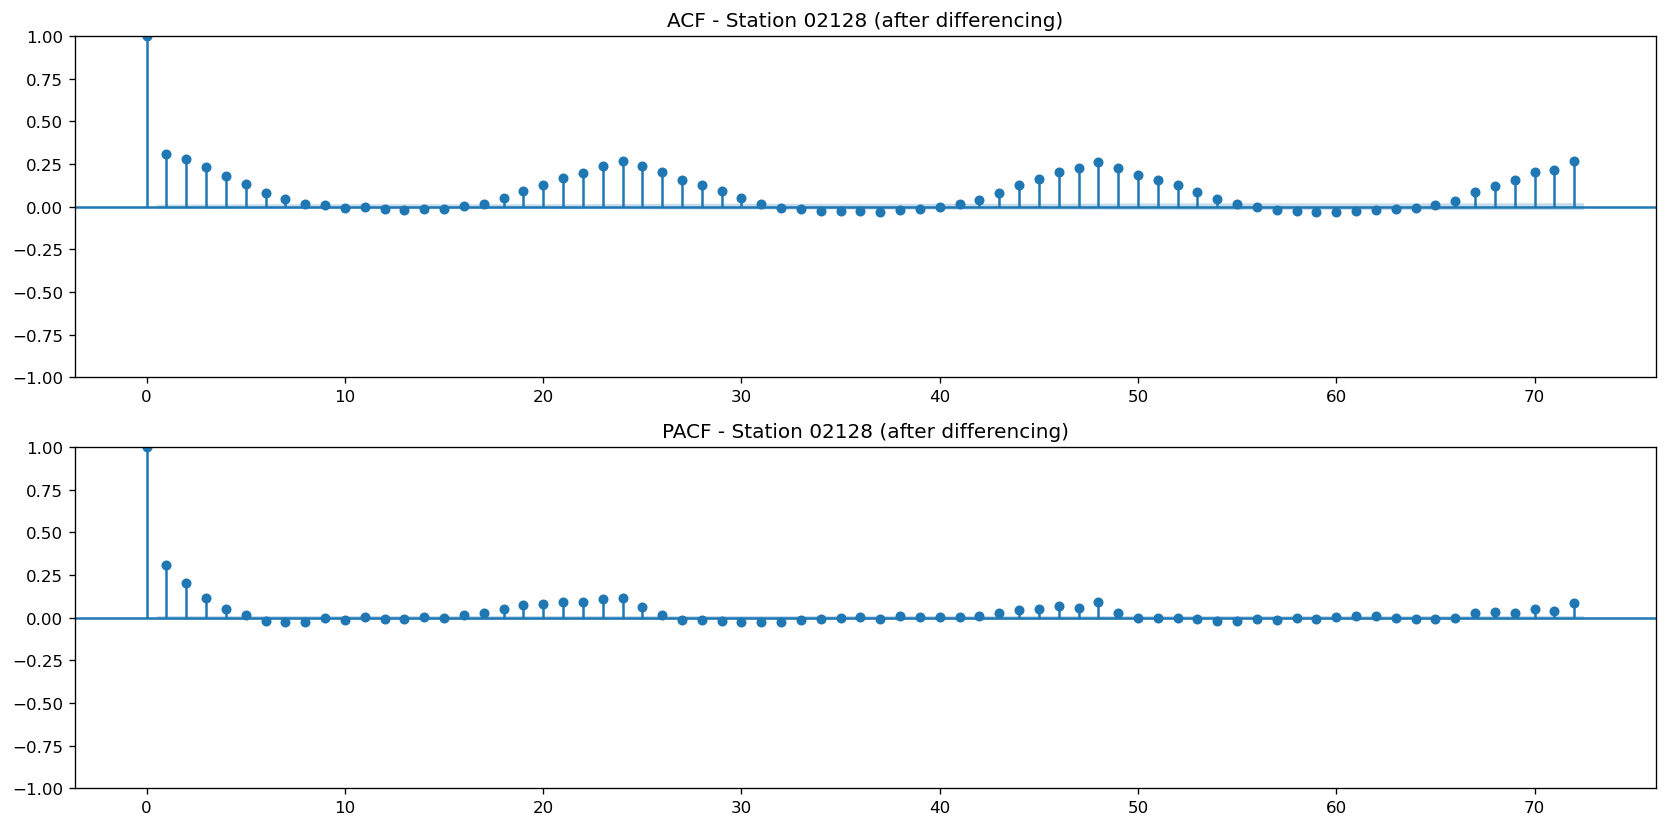

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff.dropna(), lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (after differencing)")
plot_pacf(train_diff.dropna(), lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (after differencing)")
plt.tight_layout()
plt.show()

## 6. SARIMA 모델 적합
`auto_arima`로 AIC 기준 최적 차수 자동 선택
계절 주기 **S=24** (시간 단위 데이터 → 하루 주기)


### auto_arima로 최적 차수 선택
### 이걸 코드로 변환해 돌리면 아마 돌리다가 memory issue가 날텐데, 돌려보고 싶으시면 마크다운에서 코드로 바꿔서 돌리면 됩니다!
if HAS_PMDARIMA:
    print("auto_arima 실행 중 (AIC 기준)...")
    auto_model = pm.auto_arima(
        train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        start_p=0, max_p=2,   # AR 차수 최대 2
        start_q=0, max_q=2,   # MA 차수 최대 2
        start_P=0, max_P=1,   # 계절 AR 최대 1
        start_Q=0, max_Q=1,   # 계절 MA 최대 1
        d=0,                  # ADF에서 정상 확인됐으니까 고정
        D=1,                  # 계절 차분 1회
        stepwise=True,
        information_criterion="aic",
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
    )
    order          = auto_model.order
    seasonal_order = auto_model.seasonal_order
    print(f"\n최적 차수: ARIMA{order}x{seasonal_order}")
else:
    # pmdarima 없을 때 기본값
    order          = (1, 0, 1)
    seasonal_order = (1, 1, 1, SEASONAL_PERIOD)
    print(f"기본 차수 사용: ARIMA{order}x{seasonal_order}")

In [13]:
# SARIMA 적합
# auto_arima 대신 ACF/PACF 결과 기반으로 차수 직접 고정


order          = (2, 0, 1)
seasonal_order = (1, 1, 0, SEASONAL_PERIOD)
print(f"Using fixed order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Using fixed order: ARIMA(2, 0, 1)x(1, 1, 0, 24)


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                30573
Model:             SARIMAX(2, 0, 1)x(1, 1, [], 24)   Log Likelihood              -48765.616
Date:                             Sat, 23 May 2026   AIC                          97541.232
Time:                                     00:21:48   BIC                          97582.863
Sample:                                          0   HQIC                         97554.579
                                           - 30573                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7787      0.020     39.584      0.000       0.740       0.817
ar.L2          0.0312      

## 7. ARIMAX 모델 적합
기상 데이터(기온, 강수량)를 외생변수로 추가  
기상청 데이터 수집 후 `weather.csv`로 저장하여 사용

만약 기상 데이터 처리가 어렵다고, 월별 더미로 돌리기!


In [14]:
def load_weather(data_dir: Path) -> pd.DataFrame:
    """
    Load and preprocess weather CSV files (2021-2025).
    - Keep only temperature (기온)
    - Parse datetime index
    - Resample to hourly frequency
    """
    files = sorted(data_dir.glob("*_weather.csv"))
    parts = []
    for f in files:
        df = pd.read_csv(f, encoding="cp949",
                         usecols=["일시", "기온(°C)"],
                         dtype={"기온(°C)": float})
        parts.append(df)

    weather = pd.concat(parts, ignore_index=True)
    weather["datetime"] = pd.to_datetime(weather["일시"])
    weather = (
        weather
        .set_index("datetime")
        .drop(columns=["일시"])
        .rename(columns={"기온(°C)": "temp"})
        .sort_index()
        .resample("h").mean()   # 혹시 중복 있으면 평균
    )

    # 기온 NaN 선형 보간 (거의 없지만 혹시 몰라서)
    weather["temp"] = weather["temp"].interpolate(method="linear")

    print(f"Weather data: {len(weather):,} hours")
    print(f"Period: {weather.index[0]} ~ {weather.index[-1]}")
    print(f"Temp NaN: {weather['temp'].isna().sum()}")
    return weather

weather_df = load_weather(Path("data"))  # weather CSV 폴더 경로
weather_df.head()

Weather data: 43,824 hours
Period: 2021-01-01 00:00:00 ~ 2025-12-31 23:00:00
Temp NaN: 0


,temp
datetime,
2021-01-01 00:00:00,-8.3
2021-01-01 01:00:00,-8.7
2021-01-01 02:00:00,-9.1
2021-01-01 03:00:00,-9.3
2021-01-01 04:00:00,-9.3


In [15]:
#  train/test 인덱스에 맞춰 자르기

exog_train = weather_df.loc[train.index][["temp"]]
exog_test  = weather_df.loc[test.index][["temp"]]

print("외생변수 shape:", exog_train.shape)
exog_train.head()

외생변수 shape: (30573, 1)


,temp
2021-01-01 00:00:00,-8.3
2021-01-01 01:00:00,-8.7
2021-01-01 02:00:00,-9.1
2021-01-01 03:00:00,-9.3
2021-01-01 04:00:00,-9.3


In [16]:
# ARIMAX 적합
# order          = (1, 0, 1)
# seasonal_order = (0, 1, 1, SEASONAL_PERIOD)
# print(f"Using fixed order: ARIMA{order}x{seasonal_order}")

arimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                30573
Model:             SARIMAX(2, 0, 1)x(1, 1, [], 24)   Log Likelihood              -48706.731
Date:                             Sat, 23 May 2026   AIC                          97425.463
Time:                                     00:25:36   BIC                          97475.420
Sample:                                          0   HQIC                         97441.479
                                           - 30573                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp           0.0282      0.003     10.189      0.000       0.023       0.034
ar.L1          0.7737      

## 8. 잔차 진단
| 검정 | 귀무가설 |
|------|----------|
| Ljung-Box | 잔차에 자기상관 없음 (백색잡음) |
| Jarque-Bera | 잔차가 정규분포를 따름 |
| Shapiro-Wilk | 잔차가 정규분포를 따름 |


In [17]:
def diagnose_residuals(fitted_model, model_name: str = "SARIMA"):
    residuals = pd.Series(fitted_model.resid.dropna())

    print(f"{'='*55}")
    print(f"  잔차 진단: {model_name}")
    print(f"{'='*55}")

    # 1. Ljung-Box test
    lb = acorr_ljungbox(residuals, lags=[10, 20, 48], return_df=True)
    print("\n[Ljung-Box Test] H0: 잔차에 자기상관 없음")
    print(lb[["lb_stat", "lb_pvalue"]].to_string())
    lb_pass = (lb["lb_pvalue"] > 0.05).all()
    print(f"  → {'백색잡음' if lb_pass else '자기상관 존재'}")

    # 2. Jarque-Bera test
    jb_stat, jb_pval = jarque_bera(residuals)
    print(f"\n[Jarque-Bera Test] H0: 정규분포")
    print(f"  통계량={jb_stat:.4f}, p-value={jb_pval:.4f}")
    print(f"  → {'정규성 기각 불가' if jb_pval > 0.05 else '정규성 기각'}")

    # 3. Shapiro-Wilk test
    sw_sample = residuals.sample(min(len(residuals), 5000), random_state=42)
    sw_stat, sw_pval = shapiro(sw_sample)
    print(f"\n[Shapiro-Wilk Test] H0: 정규분포")
    print(f"  통계량={sw_stat:.4f}, p-value={sw_pval:.4f}")
    print(f"  → {'정규성 기각 불가' if sw_pval > 0.05 else '정규성 기각'}")

    # 4. 잔차 시각화
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Residual Diagnostics - {model_name}", fontsize=13)

    axes[0, 0].plot(residuals.values, alpha=0.6)
    axes[0, 0].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[0, 0].set_title("Residual Time Series")

    axes[0, 1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
    axes[0, 1].set_title("Residual Histogram")

    plot_acf(residuals, lags=48, ax=axes[1, 0], title="Residual ACF")
    plot_pacf(residuals, lags=48, ax=axes[1, 1], title="Residual PACF")

    plt.tight_layout()
    plt.show()

    return {"model": model_name, "lb_pass": lb_pass,
            "jb_pval": round(jb_pval, 4), "sw_pval": round(sw_pval, 4)}


  잔차 진단: SARIMA

[Ljung-Box Test] H0: 잔차에 자기상관 없음
        lb_stat  lb_pvalue
10    11.627422   0.310765
20    31.737892   0.046173
48  4356.935561   0.000000
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=12071.3292, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9511, p-value=0.0000
  → 정규성 기각


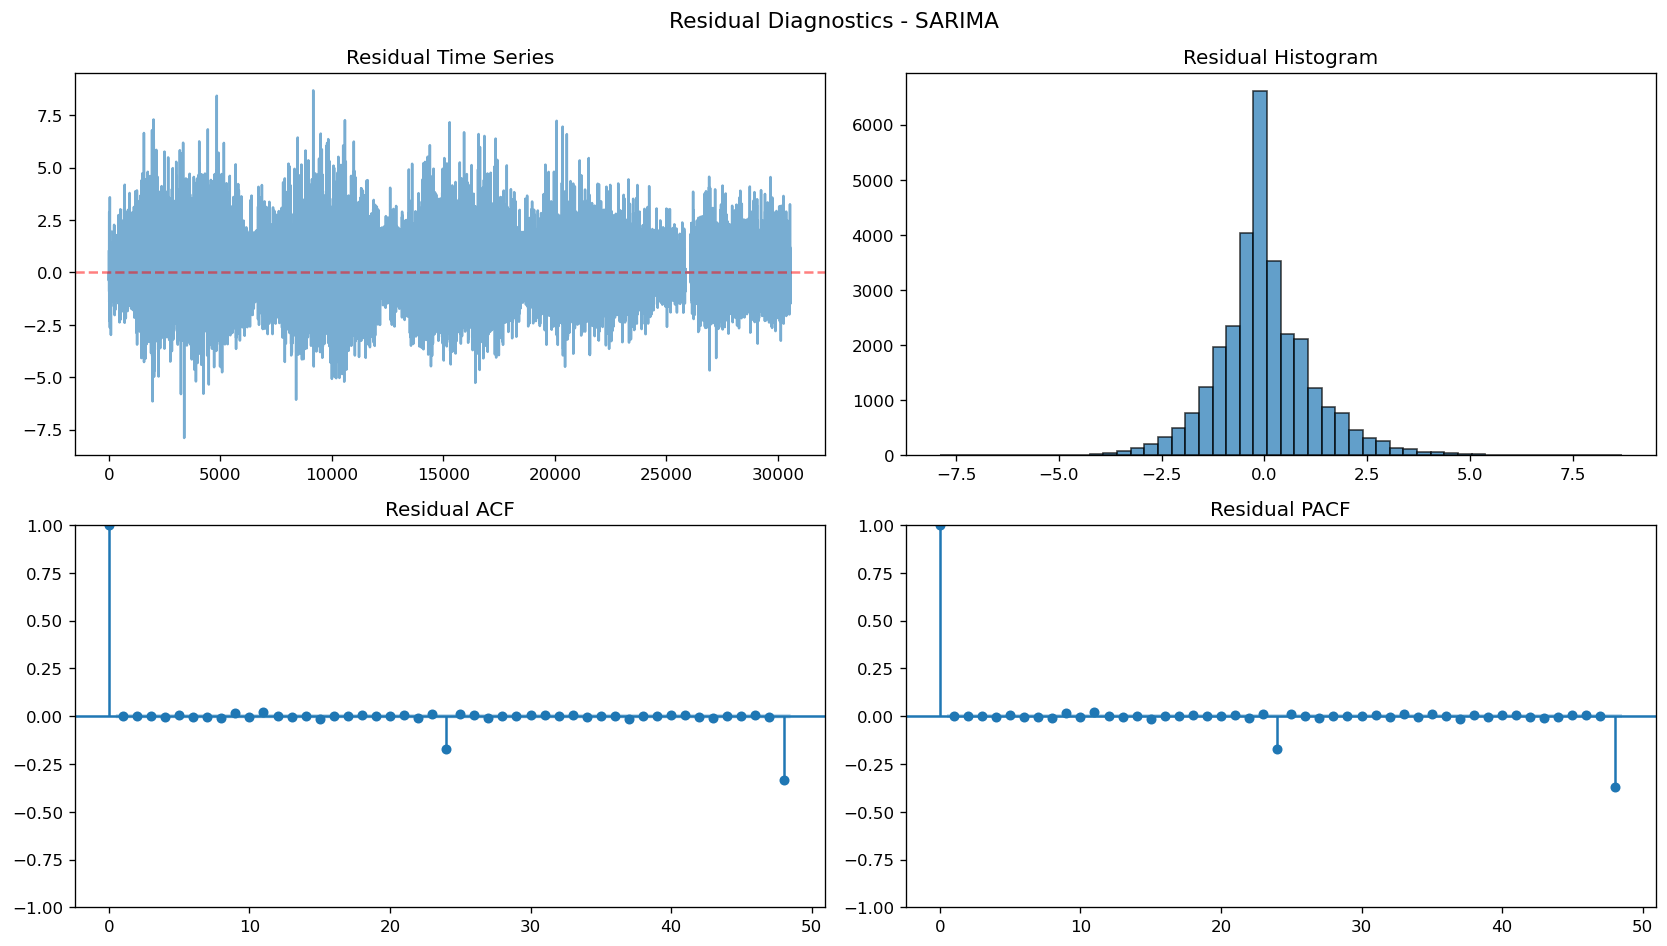

In [18]:
# SARIMA 잔차 진단
diag_sarima = diagnose_residuals(sarima_fit, model_name="SARIMA")

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
        lb_stat  lb_pvalue
10    11.796163   0.298930
20    32.274288   0.040462
48  4362.364770   0.000000
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=12086.4049, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9518, p-value=0.0000
  → 정규성 기각


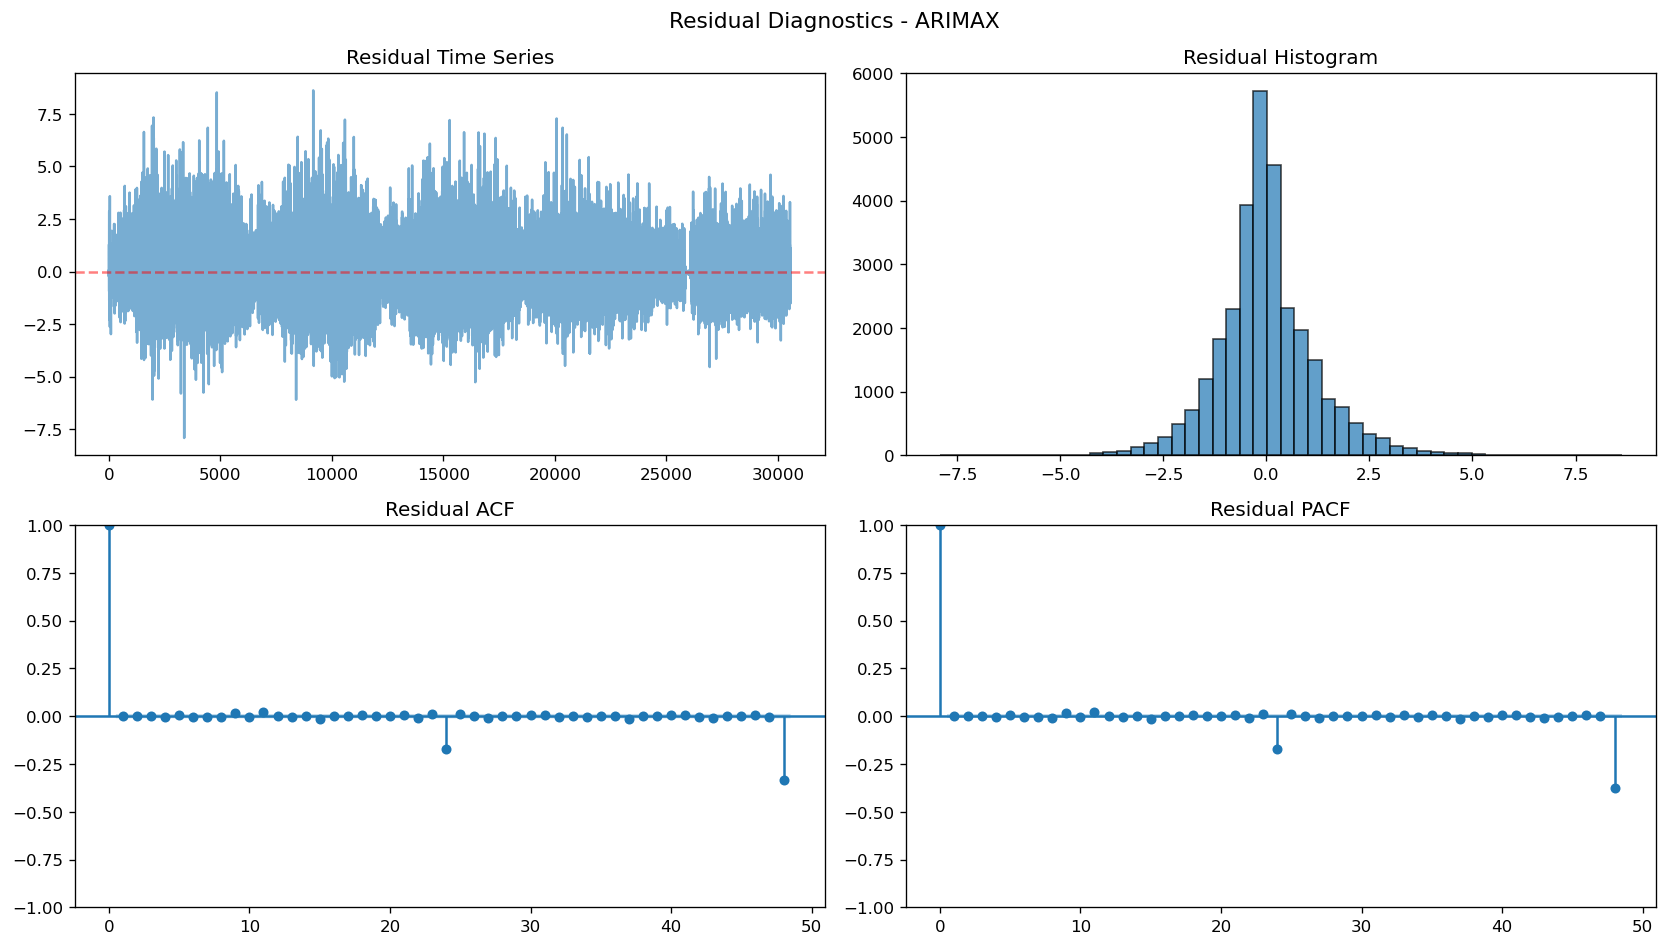

In [19]:
# ARIMAX 잔차 진단
diag_arimax = diagnose_residuals(arimax_fit, model_name="ARIMAX")

## 9. 예측 성능 평가

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 자전거 고갈 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

- $y$: 실제 대여 건수 (CNT)
- $\hat{y}$: 모델이 예측한 대여 건수
- $\alpha > 1$: 과소예측 패널티 가중치 (기본값 $\alpha=2$)


In [20]:
def asymmetric_rmse(actual: pd.Series, forecast: pd.Series,
                    alpha: float = 2.0) -> float:
    """
    비대칭 손실함수 기반 RMSE
    - 과소예측 (forecast < actual): alpha배 패널티
    - 과대예측 (forecast >= actual): 일반 패널티
    alpha=2: 과소예측 오차를 2배 강조
    """
    errors = forecast.values - actual.values
    loss = np.where(errors < 0,
                    alpha * errors**2,   # 과소예측
                    errors**2)           # 과대예측
    return float(np.sqrt(loss.mean()))


def evaluate_forecast(fitted_model, test: pd.Series,
                      model_name: str = "SARIMA",
                      exog_test: pd.DataFrame = None,
                      alpha: float = 2.0) -> dict:
    if exog_test is not None:
        forecast = fitted_model.forecast(steps=len(test), exog=exog_test)
    else:
        forecast = fitted_model.forecast(steps=len(test))

    forecast   = pd.Series(forecast.values, index=test.index)
    errors     = forecast - test   # 양수: 과대예측, 음수: 과소예측

    rmse       = np.sqrt(mean_squared_error(test, forecast))
    mae        = mean_absolute_error(test, forecast)
    asym_rmse  = asymmetric_rmse(test, forecast, alpha=alpha)
    under_rate = (errors < 0).mean() * 100

    print(f"[{model_name}]")
    print(f"  RMSE              : {rmse:.3f}")
    print(f"  MAE               : {mae:.3f}")
    print(f"  Asymmetric RMSE   : {asym_rmse:.3f}  (alpha={alpha}, 과소예측 {alpha}배 패널티)")
    print(f"  과소예측 비율      : {under_rate:.1f}%  ← 자전거 고갈 위험")

    # 시각화
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(test.index, test.values, label="Actual (y)", alpha=0.7)
    axes[0].plot(forecast.index, forecast.values,
                 label=f"Forecast y-hat ({model_name})", linestyle="--", alpha=0.8)
    axes[0].set_title(f"Forecast vs Actual - {model_name}  "
                      f"[RMSE={rmse:.2f} | Asym.RMSE={asym_rmse:.2f}]")
    axes[0].legend()

    colors = ["red" if e < 0 else "steelblue" for e in errors]
    axes[1].bar(range(len(errors)), errors.values, color=colors, alpha=0.6, width=1)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Forecast Error (y-hat - y)  |  "
                      f"Red=Under, Blue=Over  |  Under-pred={under_rate:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        f"Asym.RMSE(α={alpha})": round(asym_rmse, 3),
        "과소예측비율(%)": round(under_rate, 1),
    }


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


[SARIMA]
  RMSE              : 0.647
  MAE               : 0.484
  Asymmetric RMSE   : 0.796  (alpha=2.0, 과소예측 2.0배 패널티)
  과소예측 비율      : 25.7%  ← 자전거 고갈 위험


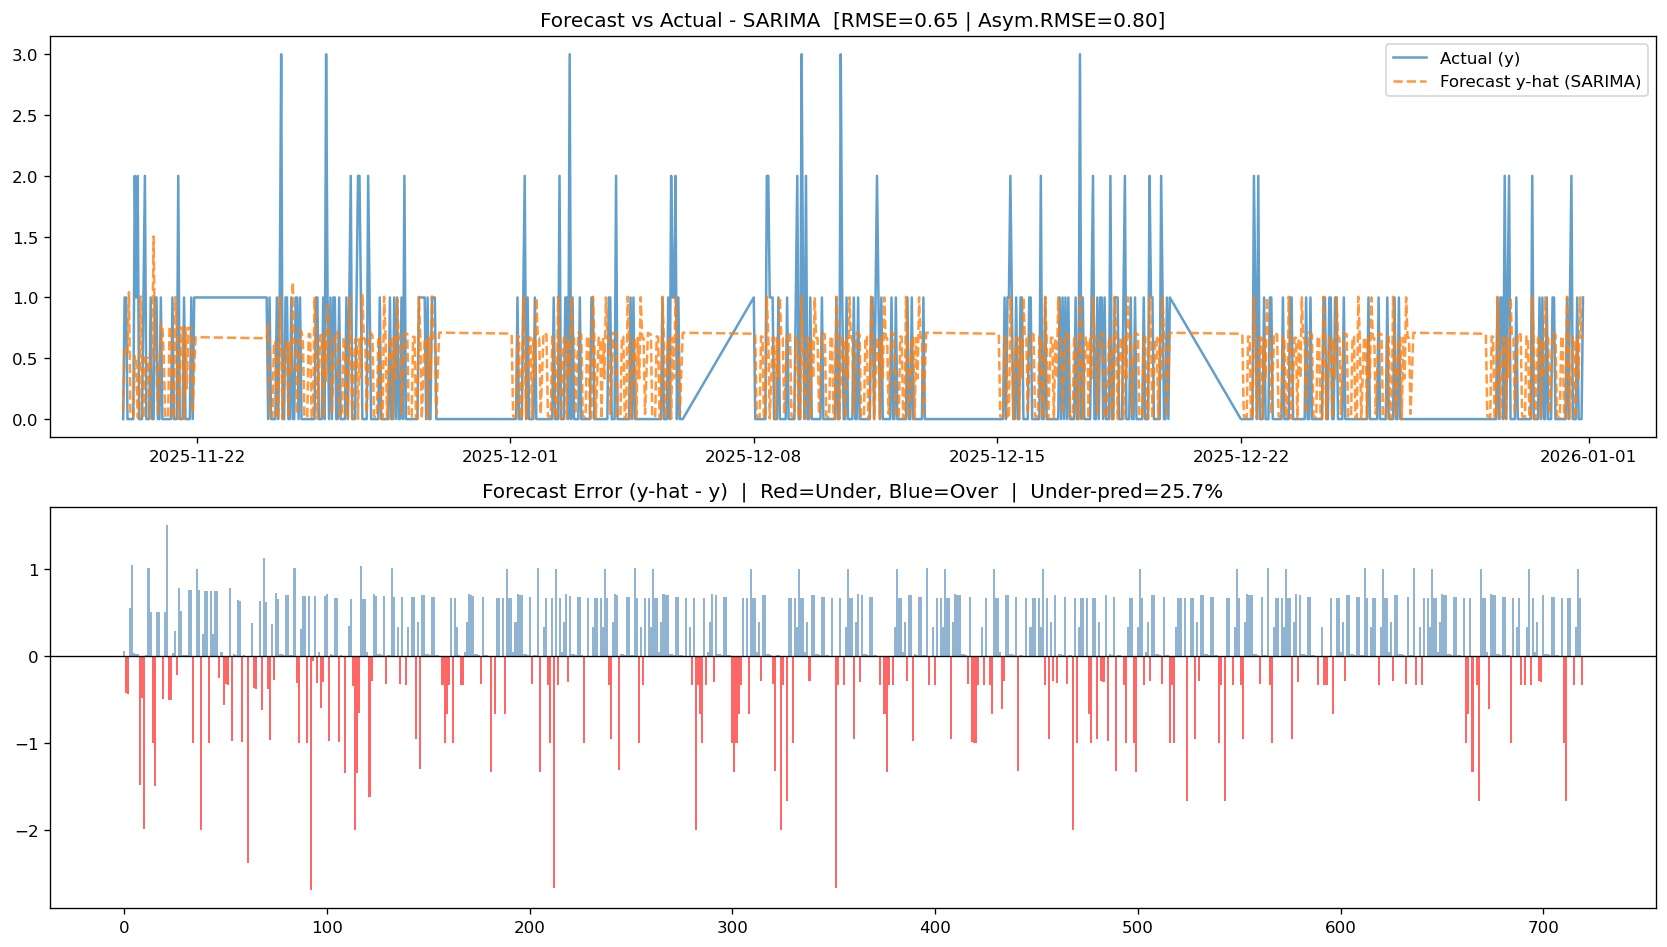

In [21]:
# alpha 설정 (과소예측 패널티 가중치)
# alpha=2: 과소예측 오차를 2배 강조 (조교님 권장 비대칭 손실)
ALPHA = 2.0

# SARIMA 예측 성능
perf_sarima = evaluate_forecast(sarima_fit, test, model_name="SARIMA", alpha=ALPHA)


c:\Users\msche\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


[ARIMAX]
  RMSE              : 0.651
  MAE               : 0.505
  Asymmetric RMSE   : 0.799  (alpha=2.0, 과소예측 2.0배 패널티)
  과소예측 비율      : 38.2%  ← 자전거 고갈 위험


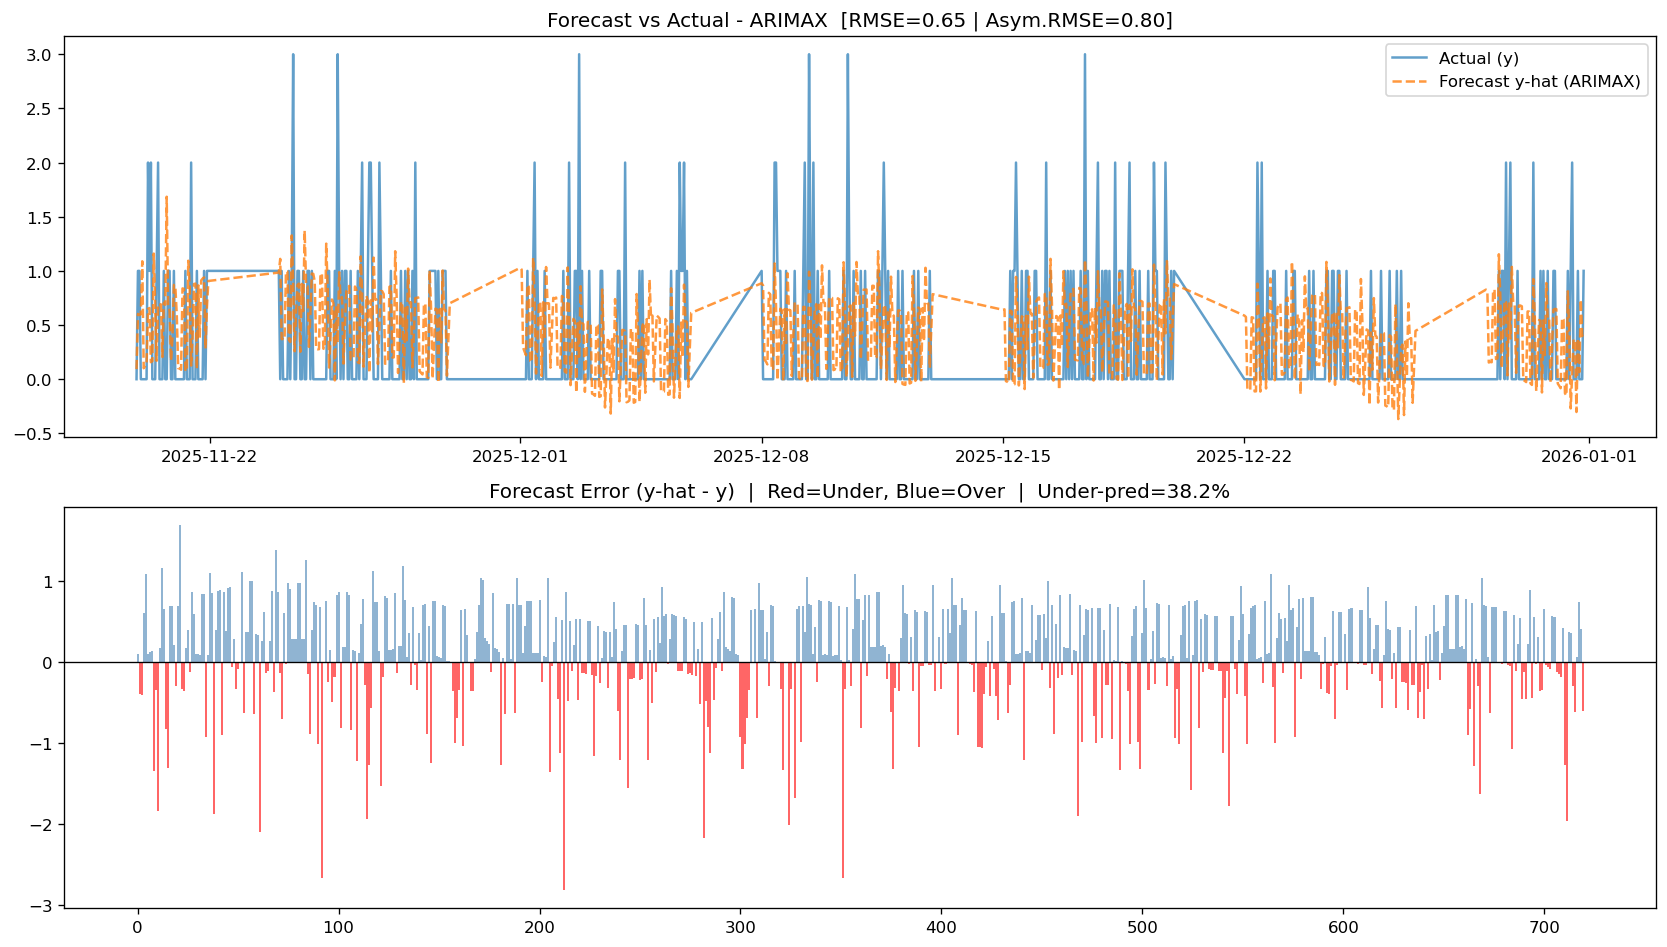

In [22]:
# alpha 설정 (과소예측 패널티 가중치)
# alpha=2: 과소예측 오차를 2배 강조 (조교님 권장 비대칭 손실)
ALPHA = 2.0

# ARIMAX 예측 성능
perf_arimax = evaluate_forecast(arimax_fit, test, model_name="ARIMAX",
                                exog_test=exog_test, alpha=ALPHA)


## 10. 모델 성능 비교


              Model Performance Comparison
         RMSE    MAE  Asym.RMSE(α=2.0)  과소예측비율(%)
model                                            
SARIMA  0.647  0.484             0.796       25.7
ARIMAX  0.651  0.505             0.799       38.2


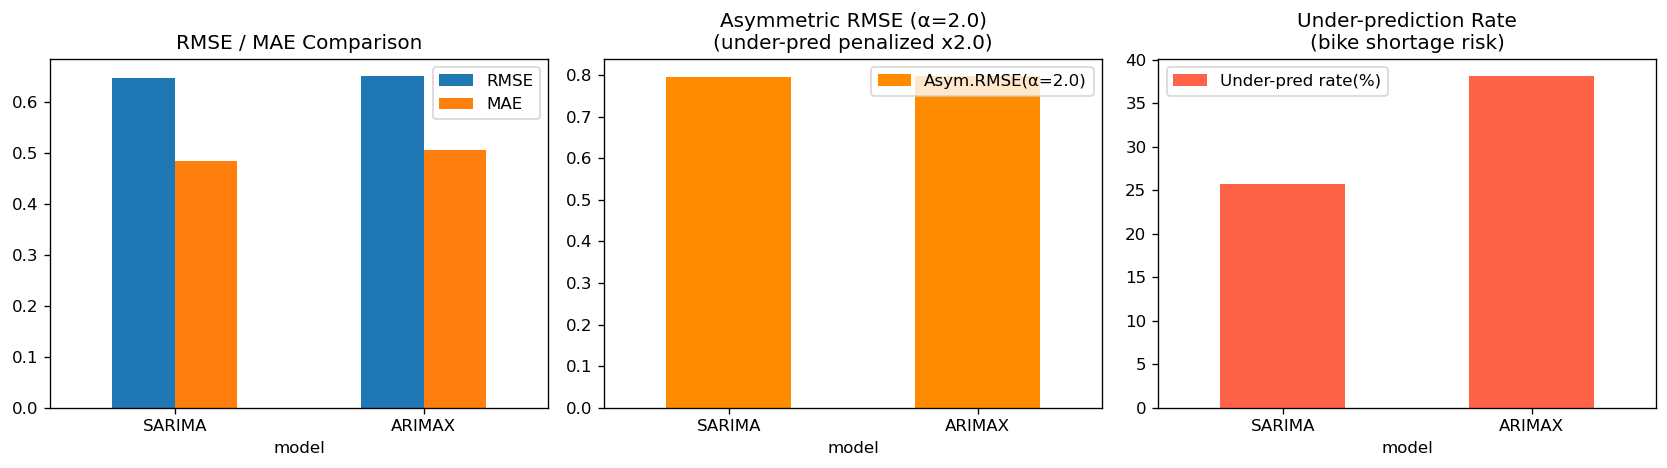

In [25]:
result_df = pd.DataFrame([perf_sarima, perf_arimax]).set_index("model")
print("\n" + "="*55)
print("              Model Performance Comparison")
print("="*55)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(α={ALPHA})"
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=0)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (α={ALPHA})\n(under-pred penalized x{ALPHA})", rot=0, color="darkorange")

result_df[["과소예측비율(%)"]].rename(
    columns={"과소예측비율(%)": "Under-pred rate(%)"}
).plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)", rot=0, color="tomato")

plt.tight_layout()
plt.show()